# Phase 3 — Attaques Adversariales (FGSM + PGD)
Objectif : tromper le modele baseline en perturbant les features manipulables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import random
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('libs OK')

libs OK


## 1. Recharger les donnees et le modele

In [2]:
def preprocess(train_df, test_df):
    drop_cols = ['id', 'attack_cat']
    train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    test_df  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
    for df in [train_df, test_df]:
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
    median_vals = train_df.median(numeric_only=True)
    train_df.fillna(median_vals, inplace=True)
    test_df.fillna(median_vals, inplace=True)
    cat_cols = [c for c in train_df.select_dtypes(include=['object','str']).columns if c != 'label']
    le = LabelEncoder()
    for col in cat_cols:
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        known = set(le.classes_)
        test_df[col] = test_df[col].astype(str).apply(lambda x: x if x in known else le.classes_[0])
        test_df[col] = le.transform(test_df[col])
    X_train = train_df.drop('label', axis=1).values.astype(np.float32)
    y_train = train_df['label'].values.astype(np.float32)
    X_test  = test_df.drop('label', axis=1).values.astype(np.float32)
    y_test  = test_df['label'].values.astype(np.float32)
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, y_train, X_test, y_test, scaler

train_df = pd.read_csv('../data/UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('../data/UNSW_NB15_testing-set.csv')
X_train, y_train, X_test, y_test, scaler = preprocess(train_df.copy(), test_df.copy())

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=X_train.shape[1])
model.load_state_dict(torch.load('../results/baseline_model.pth', weights_only=True))
model.eval()
print('Modele charge OK | Input dim:', X_train.shape[1])

Modele charge OK | Input dim: 42


## 2. Features manipulables
On perturbe uniquement les features qu'un vrai attaquant peut controler.

In [3]:
# Colonnes apres suppression de id et attack_cat
cols = pd.read_csv('../data/UNSW_NB15_training-set.csv').drop(columns=['id','attack_cat','label']).columns.tolist()
print('Toutes les features :', cols)

# Features qu'un attaquant peut modifier sans casser l'attaque
MANIPULABLE = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'sttl',
               'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'smean', 'dmean']

manipulable_idx = [cols.index(f) for f in MANIPULABLE if f in cols]
print(f'\nFeatures manipulables ({len(manipulable_idx)}) : {[cols[i] for i in manipulable_idx]}')

# Masque binaire : 1 = manipulable, 0 = interdit
mask = torch.zeros(len(cols))
mask[manipulable_idx] = 1.0
print('Masque cree OK')

Toutes les features : ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']

Features manipulables (14) : ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'sttl', 'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'smean', 'dmean']
Masque cree OK


## 3. Fonction d'evaluation

In [4]:
def evaluate(model, X, y_true, label=''):
    model.eval()
    with torch.no_grad():
        prob = model(torch.FloatTensor(X)).squeeze().numpy()
        pred = (prob >= 0.5).astype(int)
    # Evasion rate : % d'attaques classifiees comme normales
    attack_mask = (y_true == 1)
    evasion = (pred[attack_mask] == 0).mean() * 100
    results = {
        'F1'      : f1_score(y_true, pred),
        'Precision': precision_score(y_true, pred),
        'Recall'  : recall_score(y_true, pred),
        'PR-AUC'  : average_precision_score(y_true, prob),
        'Evasion%': evasion
    }
    if label:
        print(f'--- {label} ---')
        for k, v in results.items():
            print(f'  {k:12s}: {v:.4f}')
    return results

baseline_results = evaluate(model, X_test, y_test, 'Baseline (donnees propres)')

--- Baseline (donnees propres) ---
  F1          : 0.9110
  Precision   : 0.9879
  Recall      : 0.8452
  PR-AUC      : 0.9881
  Evasion%    : 15.4792


## 4. Attaque FGSM
Fast Gradient Sign Method : perturbation en un seul pas dans la direction du gradient.

In [5]:
def fgsm_attack(model, X, y, epsilon, mask):
    X_t = torch.FloatTensor(X).requires_grad_(True)
    y_t = torch.FloatTensor(y)
    loss = nn.BCELoss()(model(X_t).squeeze(), y_t)
    loss.backward()
    # Perturbation dans la direction du gradient, masquee
    perturbation = epsilon * X_t.grad.sign() * mask
    return (X_t + perturbation).detach().numpy()

# Tester sur les exemples d'attaque uniquement
attack_idx = np.where(y_test == 1)[0]
X_attacks  = X_test[attack_idx]
y_attacks  = y_test[attack_idx]

print('=== FGSM ===')
for eps in [0.05, 0.1, 0.3]:
    X_fgsm = fgsm_attack(model, X_attacks, y_attacks, epsilon=eps, mask=mask)
    # Recombiner avec les exemples normaux pour l'evaluation complete
    X_full = X_test.copy()
    X_full[attack_idx] = X_fgsm
    res = evaluate(model, X_full, y_test, f'FGSM eps={eps}')

=== FGSM ===
--- FGSM eps=0.05 ---
  F1          : 0.8754
  Precision   : 0.9870
  Recall      : 0.7865
  PR-AUC      : 0.9845
  Evasion%    : 21.3464
--- FGSM eps=0.1 ---
  F1          : 0.8533
  Precision   : 0.9864
  Recall      : 0.7518
  PR-AUC      : 0.9819
  Evasion%    : 24.8171
--- FGSM eps=0.3 ---
  F1          : 0.7856
  Precision   : 0.9844
  Recall      : 0.6536
  PR-AUC      : 0.9773
  Evasion%    : 34.6419


## 5. Attaque PGD
Projected Gradient Descent : version iterative de FGSM, plus puissante.

In [6]:
def pgd_attack(model, X, y, epsilon, alpha, steps, mask):
    X_orig = torch.FloatTensor(X)
    X_adv  = X_orig.clone()
    y_t    = torch.FloatTensor(y)
    for _ in range(steps):
        X_adv = X_adv.detach().requires_grad_(True)
        loss  = nn.BCELoss()(model(X_adv).squeeze(), y_t)
        loss.backward()
        X_adv = X_adv + alpha * X_adv.grad.sign() * mask
        # Projection dans la boule epsilon
        delta = torch.clamp(X_adv - X_orig, -epsilon, epsilon)
        X_adv = (X_orig + delta).detach()
    return X_adv.numpy()

print('=== PGD ===')
for eps in [0.05, 0.1, 0.3]:
    X_pgd = pgd_attack(model, X_attacks, y_attacks, epsilon=eps, alpha=0.01, steps=40, mask=mask)
    X_full = X_test.copy()
    X_full[attack_idx] = X_pgd
    res = evaluate(model, X_full, y_test, f'PGD eps={eps}')

=== PGD ===
--- PGD eps=0.05 ---
  F1          : 0.8730
  Precision   : 0.9869
  Recall      : 0.7827
  PR-AUC      : 0.9837
  Evasion%    : 21.7327
--- PGD eps=0.1 ---
  F1          : 0.8306
  Precision   : 0.9857
  Recall      : 0.7176
  PR-AUC      : 0.9782
  Evasion%    : 28.2376
--- PGD eps=0.3 ---
  F1          : 0.6850
  Precision   : 0.9807
  Recall      : 0.5263
  PR-AUC      : 0.9619
  Evasion%    : 47.3727


## 6. Graphique comparatif

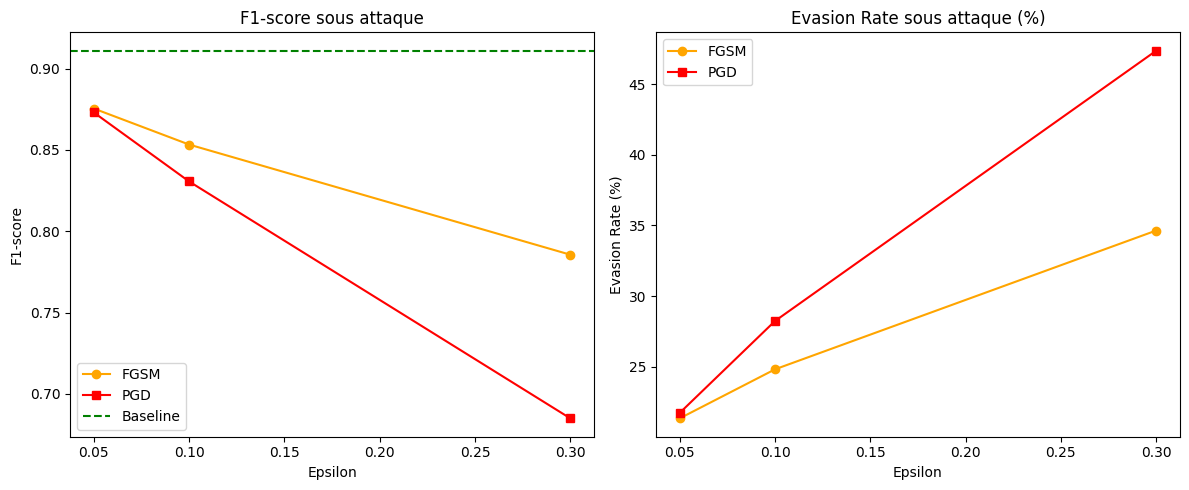

Sauvegarde : results/attack_comparison.png
=> Phase 4 : defenses


In [7]:
epsilons = [0.05, 0.1, 0.3]
f1_fgsm, evasion_fgsm = [], []
f1_pgd,  evasion_pgd  = [], []

for eps in epsilons:
    # FGSM
    X_full = X_test.copy()
    X_full[attack_idx] = fgsm_attack(model, X_attacks, y_attacks, eps, mask)
    r = evaluate(model, X_full, y_test)
    f1_fgsm.append(r['F1'])
    evasion_fgsm.append(r['Evasion%'])
    # PGD
    X_full = X_test.copy()
    X_full[attack_idx] = pgd_attack(model, X_attacks, y_attacks, eps, 0.01, 40, mask)
    r = evaluate(model, X_full, y_test)
    f1_pgd.append(r['F1'])
    evasion_pgd.append(r['Evasion%'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(epsilons, f1_fgsm, 'o-', label='FGSM', color='orange')
ax1.plot(epsilons, f1_pgd,  's-', label='PGD',  color='red')
ax1.axhline(baseline_results['F1'], linestyle='--', color='green', label='Baseline')
ax1.set_title('F1-score sous attaque')
ax1.set_xlabel('Epsilon')
ax1.set_ylabel('F1-score')
ax1.legend()

ax2.plot(epsilons, evasion_fgsm, 'o-', label='FGSM', color='orange')
ax2.plot(epsilons, evasion_pgd,  's-', label='PGD',  color='red')
ax2.set_title('Evasion Rate sous attaque (%)')
ax2.set_xlabel('Epsilon')
ax2.set_ylabel('Evasion Rate (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('../results/attack_comparison.png', dpi=150)
plt.show()
print('Sauvegarde : results/attack_comparison.png')
print('=> Phase 4 : defenses')